<a href="https://colab.research.google.com/github/aniketbk7247/IOT-Attack-Detection-/blob/main/iot_attacks_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Exploratory Data Analysis**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
eda_df = pd.read_csv("/content/drive/MyDrive/IoT_Attack/RT_IOT2022.csv")
eda_df.head(5)

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [ ]:
eda_df.tail(5)

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
123112,2005,59247,63331,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,2006,59247,64623,tcp,-,0.000007,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,2007,59247,64680,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,2008,59247,65000,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123116,2009,59247,65129,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


In [ ]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   no                        123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

In [ ]:
eda_df.describe()

,no,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,37035.089248,34639.258738,1014.305092,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,30459.106367,19070.620354,5256.371994,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,6059.000000,17702.000000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,33100.000000,37221.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,63879.000000,50971.000000,21.000000,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,94658.000000,65535.000000,65389.000000,21728.335578,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


In [ ]:
#Check for Null Values
eda_df.isnull().sum()

,0
no,0
id.orig_p,0
id.resp_p,0
proto,0
service,0
...,...
idle.std,0
fwd_init_window_size,0
bwd_init_window_size,0
fwd_last_window_size,0


In [ ]:
eda_df.shape

(123117, 85)

In [ ]:
eda_df.dtypes

,0
no,int64
id.orig_p,int64
id.resp_p,int64
proto,object
service,object
...,...
idle.std,float64
fwd_init_window_size,int64
bwd_init_window_size,int64
fwd_last_window_size,int64


In [ ]:
eda_df.columns

Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max', 'flow_pkts_payload.tot',
  

**Data Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Correlation Matrix for Numerical features
#Visualize the correlations using a heatmap to understand which of the features are strongly or inversely correlated.
numeric_df = eda_df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(120, 120))
sns.heatmap(correlation_matrix, annot=False, cmap='PuBuGn')
plt.title("Correlation Matrix (Heatmap)")
plt.show()

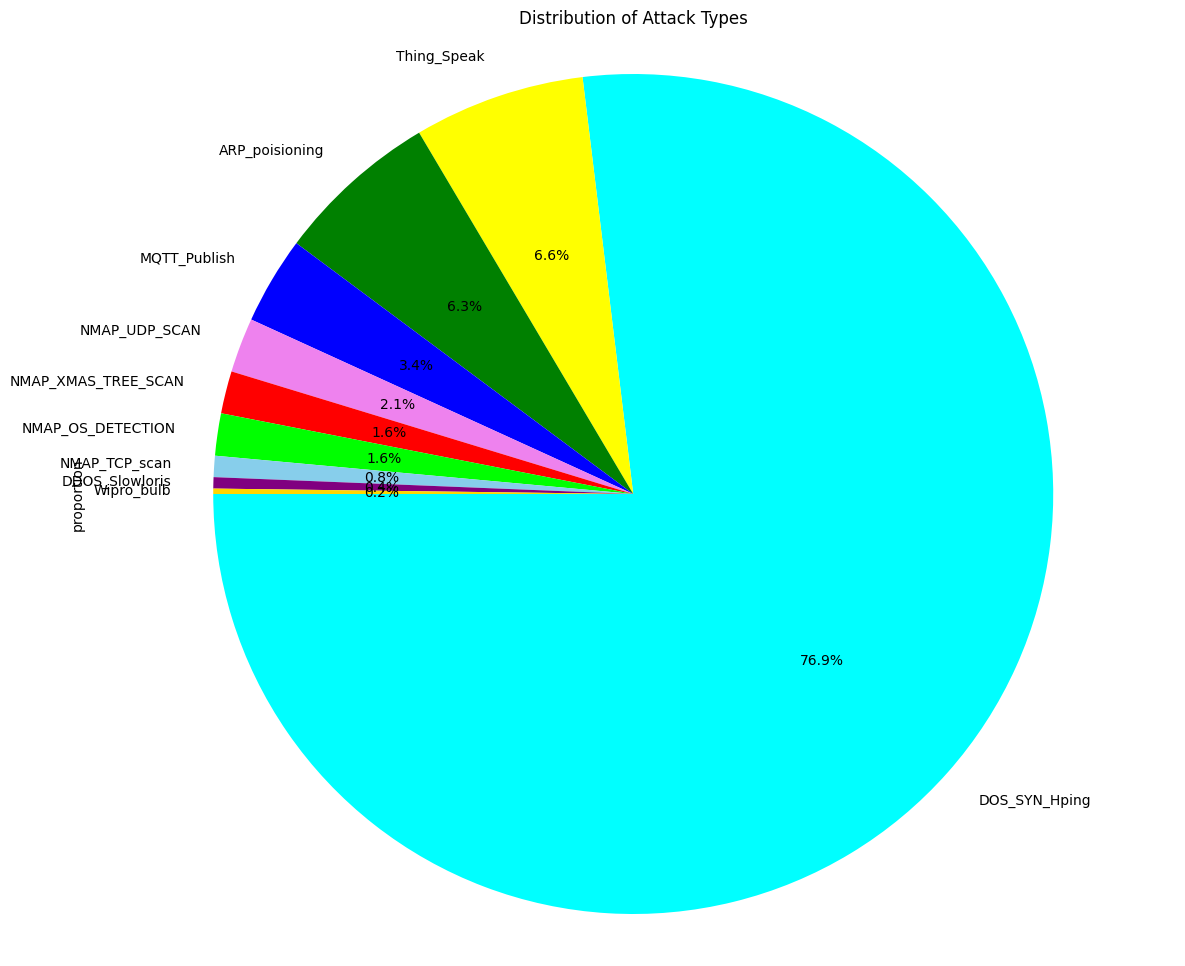

In [ ]:
# Pie chart wrt attack types
colors = ['cyan', 'yellow', 'green', 'blue', 'violet', 'red', 'lime', 'skyblue', 'purple', 'gold', '#6AC9A1', '#F37167']
plt.figure(figsize=(14, 12))
attack_type_freq = eda_df['Attack_type'].value_counts(normalize=True)
filtered_attack_freq = attack_type_freq[attack_type_freq >= 0.001]
filtered_attack_freq.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=180)
plt.title("Distribution of Attack Types")
plt.axis('equal')
plt.show()

/tmp/ipython-input-2196003865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=eda_df, palette=custom_colors)
/tmp/ipython-input-2196003865.py:5: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.countplot(x=col, data=eda_df, palette=custom_colors)


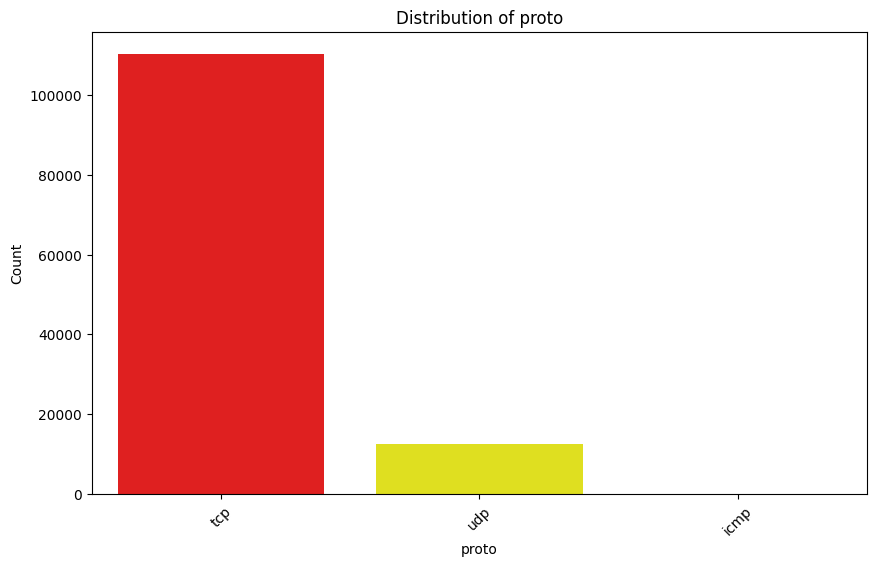

/tmp/ipython-input-2196003865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=eda_df, palette=custom_colors)
/tmp/ipython-input-2196003865.py:5: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.countplot(x=col, data=eda_df, palette=custom_colors)


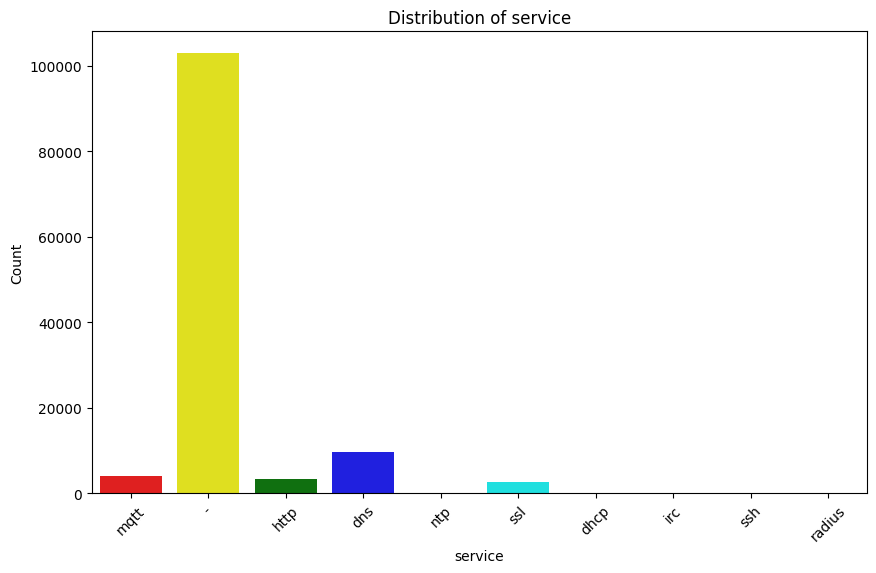

/tmp/ipython-input-2196003865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=eda_df, palette=custom_colors)


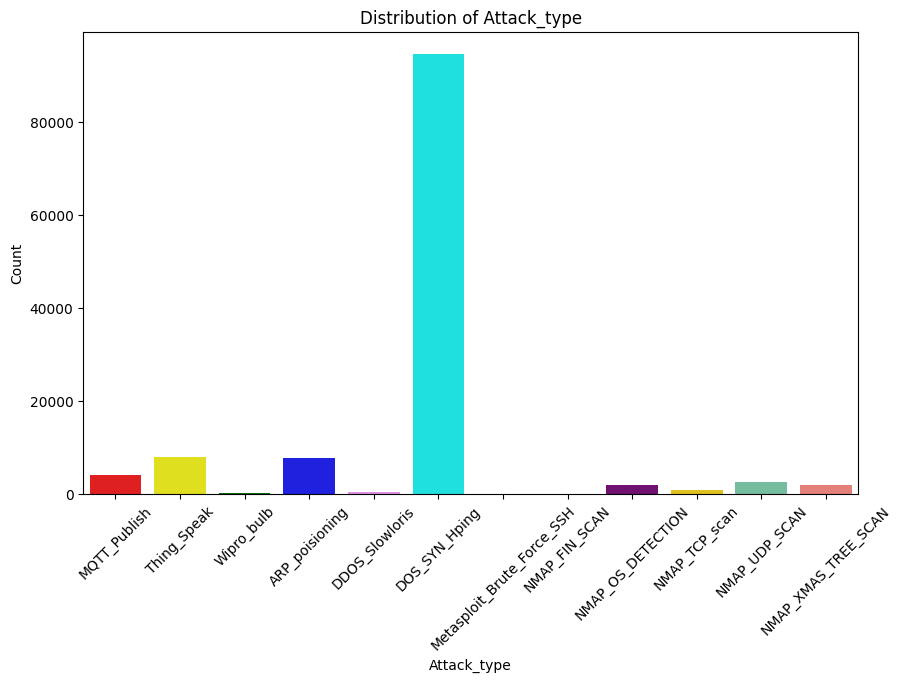

In [ ]:
custom_colors = ['red', 'yellow', 'green', 'blue', 'violet', 'cyan', 'lime', 'skyblue', 'purple', 'gold', '#6AC9A1', '#F37167']
categorical_columns = ['proto', 'service', 'Attack_type']
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, data=eda_df, palette=custom_colors)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

**Note:** Distribution of categorical variables within the DataFrame.

**Data Preprocessing/Preparation**

In [ ]:
from sklearn.preprocessing import LabelEncoder
X = eda_df.drop(columns=['no', 'Attack_type'])
y = eda_df['Attack_type']
labelencoder = LabelEncoder()
X['proto'] = labelencoder.fit_transform(X['proto'])
X['service'] = labelencoder.fit_transform(X['service'])

**Model Training**

In [ ]:
from sklearn.model_selection import train_test_split

#Split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize classifiers
classifiers = {
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

# Iterate through classifiers, train, predict, and evaluate
for clf_name, clf in classifiers.items():
    print(f"Training and evaluating {clf_name}...")

    # Train the classifier
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Print confusion matrix and classification report
    print(f"Confusion Matrix for {clf_name}:", confusion_matrix(y_test, y_pred))
    print("***********************************\n")
    print(f"Classification Report for {clf_name}:\n", classification_report(y_test, y_pred))
    print("-" * 50)  # Separator for clarity

Training and evaluating SVM...
Confusion Matrix for SVM: [[  262     0  1202     8     0     0     0     0     0     0    79     1]
 [   56     0    52     0     0     0     0     0     0     0     0     0]
 [    0     0 18916     0     0     0     0     0     0     0     0     0]
 [   21     0     0   804     0     0     0     0     0     0    37     0]
 [    0     0     1     0     0     0     0     0     0     0     7     0]
 [    0     0     6     0     0     0     0     0     0     0     0     0]
 [    0     0   413     0     0     0     0     0     0     0     0     0]
 [    0     0   204     0     0     0     0     0     0     0     0     0]
 [    1     0   499     0     0     0     0     0     0     0     0     0]
 [    0     0   389     0     0     0     0     0     0     0     0     0]
 [   13     0  1453     4     0     0     0     0     0     0   146     0]
 [   16     0    32     0     0     0     0     0     0     0     1     1]]
***********************************



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for SVM:
                             precision    recall  f1-score   support

            ARP_poisioning       0.71      0.17      0.27      1552
            DDOS_Slowloris       0.00      0.00      0.00       108
             DOS_SYN_Hping       0.82      1.00      0.90     18916
              MQTT_Publish       0.99      0.93      0.96       862
Metasploit_Brute_Force_SSH       0.00      0.00      0.00         8
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.00      0.00      0.00       413
             NMAP_TCP_scan       0.00      0.00      0.00       204
             NMAP_UDP_SCAN       0.00      0.00      0.00       500
       NMAP_XMAS_TREE_SCAN       0.00      0.00      0.00       389
               Thing_Speak       0.54      0.09      0.15      1616
                Wipro_bulb       0.50      0.02      0.04        50

                  accuracy                           0.82     24624
              